# Análise da relação entre indicadores econômicos brasileiros e ações da B3

## 1. Introdução

Este notebook descreve historicamente uma amostra de ações negociadas na B3 e indicadores macroeconômicos brasileiros entre março de 2012 e dezembro de 2024. Nesta etapa são realizadas apenas análise exploratória, estatística descritiva e visualização. Não são utilizados algoritmos de predição e ainda não são calculadas correlações entre as bases.

As observações devem ser interpretadas como descrições históricas da amostra, sem inferência de causalidade ou recomendação de investimento.

## 2. Dados utilizados

A análise utiliza exclusivamente os dados processados:

- `data/processed/stocks_monthly.csv`;
- `data/processed/economic_indicators_monthly.csv`.

A base de ações contém métricas mensais calculadas com `Adj Close` para retorno e volatilidade. `Close` é mantido como referência não ajustada. A amostra possui 215 tickers selecionados por critérios de cobertura e qualidade.

## 3. Preparação dos dados

A limpeza e a agregação foram executadas por `prepare_data.py`. Os dados brutos não são alterados. Indicadores originalmente mensais não foram replicados para frequência diária. A Selic possui média mensal, valor ao final do mês e variação mensal em pontos.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().parent if (Path.cwd() / 'data').exists() is False else Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path.cwd().parent
TABLES = ROOT / 'outputs' / 'tables'
FIGURES = ROOT / 'outputs' / 'figures'
stocks = pd.read_csv(ROOT / 'data' / 'processed' / 'stocks_monthly.csv')
economic = pd.read_csv(ROOT / 'data' / 'processed' / 'economic_indicators_monthly.csv')
stocks['month'] = pd.PeriodIndex(stocks['month'], freq='M')
economic['month'] = pd.PeriodIndex(economic['month'], freq='M')
print(f'Ações: {len(stocks):,} observações mensais; {stocks.Symbol.nunique()} tickers')
print(f'Indicadores: {len(economic):,} meses')
display(stocks.head())
display(economic.head())

Ações: 29,415 observações mensais; 215 tickers
Indicadores: 154 meses


,Symbol,month,month_end_close,month_end_adj_close,volume_mean,volume_total,valid_sessions,volatility_daily_return,previous_month_end_adj_close,previous_month,monthly_return
0,ABTT34,2012-05,30.309999,25.153019,922.727273,20300.0,22,0.000000,NaN,NaN,NaN
1,ABTT34,2012-06,30.309999,25.153019,0.000000,0.0,20,0.000000,25.153019,2012-05,0.000000
2,ABTT34,2012-07,30.309999,25.368477,0.000000,0.0,21,0.001869,25.153019,2012-06,0.008566
3,ABTT34,2012-08,30.309999,25.368477,0.000000,0.0,23,0.000000,25.368477,2012-07,0.000000
4,ABTT34,2012-09,35.459999,29.678850,110.526316,2100.0,19,0.038980,25.368477,2012-08,0.169911


,month,selic_media_mensal,selic_final_mes,ipca,igpm,inpc,desemprego_pnadc,selic_variacao_mensal_pontos
0,2012-03,9.919355,9.75,0.21,0.43,0.18,8.0,-0.75
1,2012-04,9.450000,9.00,0.64,0.85,0.64,7.8,-0.75
2,2012-05,8.983871,8.50,0.36,1.02,0.55,7.7,-0.50
3,2012-06,8.500000,8.50,0.08,0.66,0.26,7.6,0.00
4,2012-07,8.177419,8.00,0.43,1.34,0.43,7.5,-0.50


## 4. Análise exploratória

### 4.1 Ações da B3

As tabelas abaixo resumem retorno mensal, volatilidade diária mensal, volumes e quantidade de sessões válidas. Valores extremos são preservados; a tabela específica de extremos registra os tickers e meses correspondentes.

In [2]:
stock_stats = pd.read_csv(TABLES / 'stock_descriptive_statistics.csv')
stock_extremes = pd.read_csv(TABLES / 'stock_return_extremes.csv')
display(stock_stats)
display(stock_extremes.head(10))

,metric,count,missing,mean,median,std,min,q25,q75,max
0,monthly_return,29193,222,1.229005e-02,0.000000,2.019925e-01,-0.9375,-0.052632,5.676324e-02,1.196296e+01
1,volatility_daily_return,29404,11,2.547452e-02,0.020279,4.834014e-02,0.0000,0.013006,3.025135e-02,4.518701e+00
2,volume_mean,29415,0,2.245583e+06,23822.727273,7.894666e+06,0.0000,361.904762,1.278142e+06,2.008178e+08
3,volume_total,29415,0,4.502936e+07,480386.000000,1.602430e+08,0.0000,7240.000000,2.532895e+07,4.618809e+09
4,valid_sessions,29415,0,2.028815e+01,21.000000,2.506723e+00,1.0000,19.000000,2.200000e+01,2.300000e+01


,extreme_type,Symbol,month,monthly_return,volatility_daily_return,valid_sessions
0,highest_return,XRXB34,2017-09,2.439234,0.479331,21
1,highest_return,RPMG3,2019-07,2.478261,0.226095,22
2,highest_return,PDGR3,2016-02,2.663366,0.128724,19
3,highest_return,BSLI4,2021-01,2.870873,0.536933,19
4,highest_return,SLED3,2019-08,3.011765,0.491777,22
5,highest_return,BSLI3,2021-01,3.095577,0.405240,19
6,highest_return,CTNM3,2018-01,3.150000,0.194928,22
7,highest_return,CTKA4,2017-01,3.227273,0.257923,21
8,highest_return,LUPA3,2016-07,3.492064,0.174407,21
9,highest_return,MMXM11,2020-10,3.632353,0.713912,21


### 4.2 Indicadores econômicos

As estatísticas econômicas mantêm as unidades originais: taxas em percentual, índices de inflação em variação mensal percentual e variação da Selic em pontos percentuais.

In [3]:
economic_stats = pd.read_csv(TABLES / 'economic_descriptive_statistics.csv')
display(economic_stats)

,metric,count,missing,mean,median,std,min,q25,q75,max,period_start,period_end
0,selic_media_mensal,154,0,9.407396,10.169355,3.681859,2.00,6.5000,12.7625,14.25,2012-03,2024-12
1,selic_final_mes,154,0,9.413961,10.125000,3.688369,2.00,6.5000,12.7500,14.25,2012-03,2024-12
2,selic_variacao_mensal_pontos,154,0,0.011364,0.000000,0.440348,-1.00,0.0000,0.0000,1.50,2012-03,2024-12
3,ipca,154,0,0.472727,0.435000,0.374737,-0.68,0.2400,0.6850,1.62,2012-03,2024-12
4,igpm,154,0,0.608312,0.530000,0.959982,-1.93,0.1500,0.9475,4.34,2012-03,2024-12
5,inpc,154,0,0.472532,0.450000,0.403280,-0.60,0.1825,0.7050,1.71,2012-03,2024-12
6,desemprego_pnadc,154,0,10.045455,9.450000,2.664756,6.10,7.5250,12.3000,14.90,2012-03,2024-12


### 4.3 Comportamento agregado da amostra

A série agregada representa o comportamento típico dos ativos selecionados, e não um índice de mercado. A mediana é priorizada porque reduz a influência de retornos extremos. A quantidade de ativos válidos é mostrada para evidenciar mudanças na composição da amostra.

In [4]:
market_summary = pd.read_csv(TABLES / 'monthly_market_summary.csv')
extremes = pd.read_csv(TABLES / 'extreme_months.csv')
display(market_summary.head())
display(extremes)

,month,median_monthly_return,mean_monthly_return,median_volatility,mean_volatility,assets_with_month_data,valid_return_assets,positive_return_assets,negative_return_assets,positive_return_proportion,negative_return_proportion
0,2012-03,0.000000,0.021242,0.018441,0.019974,186,184,87,60,0.472826,0.326087
1,2012-04,0.000000,-0.008848,0.016315,0.017826,189,186,76,88,0.408602,0.473118
2,2012-05,-0.047619,-0.044627,0.021505,0.024927,193,189,40,124,0.211640,0.656085
3,2012-06,0.000000,-0.000294,0.019655,0.020006,194,193,90,56,0.466321,0.290155
4,2012-07,0.000000,0.012326,0.019401,0.018782,196,194,81,69,0.417526,0.355670


,metric,direction,rank,month,value,valid_return_assets
0,median_monthly_return,lowest,1,2020-03,-0.263623,210
1,median_monthly_return,lowest,2,2022-06,-0.082126,213
2,median_monthly_return,lowest,3,2022-11,-0.067404,210
3,median_monthly_return,lowest,4,2020-02,-0.066172,210
4,median_monthly_return,lowest,5,2013-06,-0.062572,200
5,median_monthly_return,lowest,6,2018-05,-0.057687,210
6,median_monthly_return,lowest,7,2015-08,-0.056250,209
7,median_monthly_return,lowest,8,2022-12,-0.055620,207
8,median_monthly_return,lowest,9,2018-06,-0.053392,210
9,median_monthly_return,lowest,10,2021-10,-0.053130,210


## 5. Visualizações

Os gráficos foram gerados a partir das tabelas processadas. A distribuição dos retornos possui uma versão completa e outra limitada visualmente aos percentis 1 e 99; nenhum dado foi removido da análise.

- **Selic:** mostra a trajetória da média mensal e do valor ao fim do mês.
- **Inflação:** compara IPCA, IGP-M e INPC, todos em variação mensal percentual.
- **Desemprego:** mostra a série mensal do desemprego PNADC.
- **Retorno típico:** acompanha a mediana mensal dos retornos e apresenta a média apenas como referência.
- **Volatilidade:** acompanha a mediana e a média da volatilidade dos retornos diários.
- **Distribuição:** mostra a dispersão dos retornos completos e uma versão visual sem os extremos das caudas.
- **Proporções:** compara a parcela mensal de ativos com retorno positivo e negativo.
- **Disponibilidade:** acompanha a quantidade de ativos disponíveis e com retorno válido por mês.

A evolução da Selic média mensal e ao final do mês.


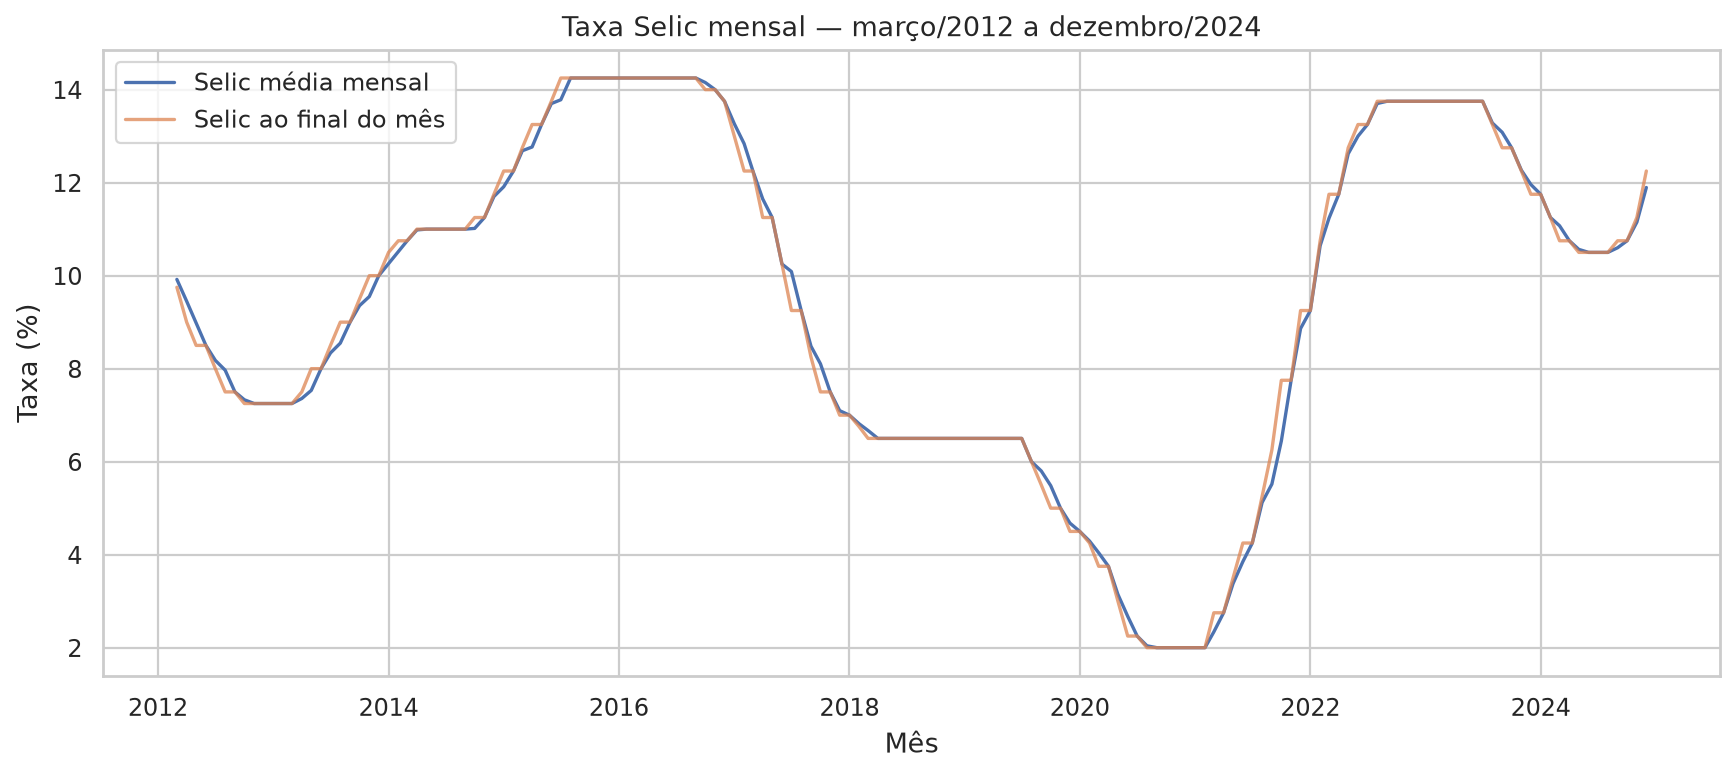

A evolução comparada dos índices mensais de inflação.


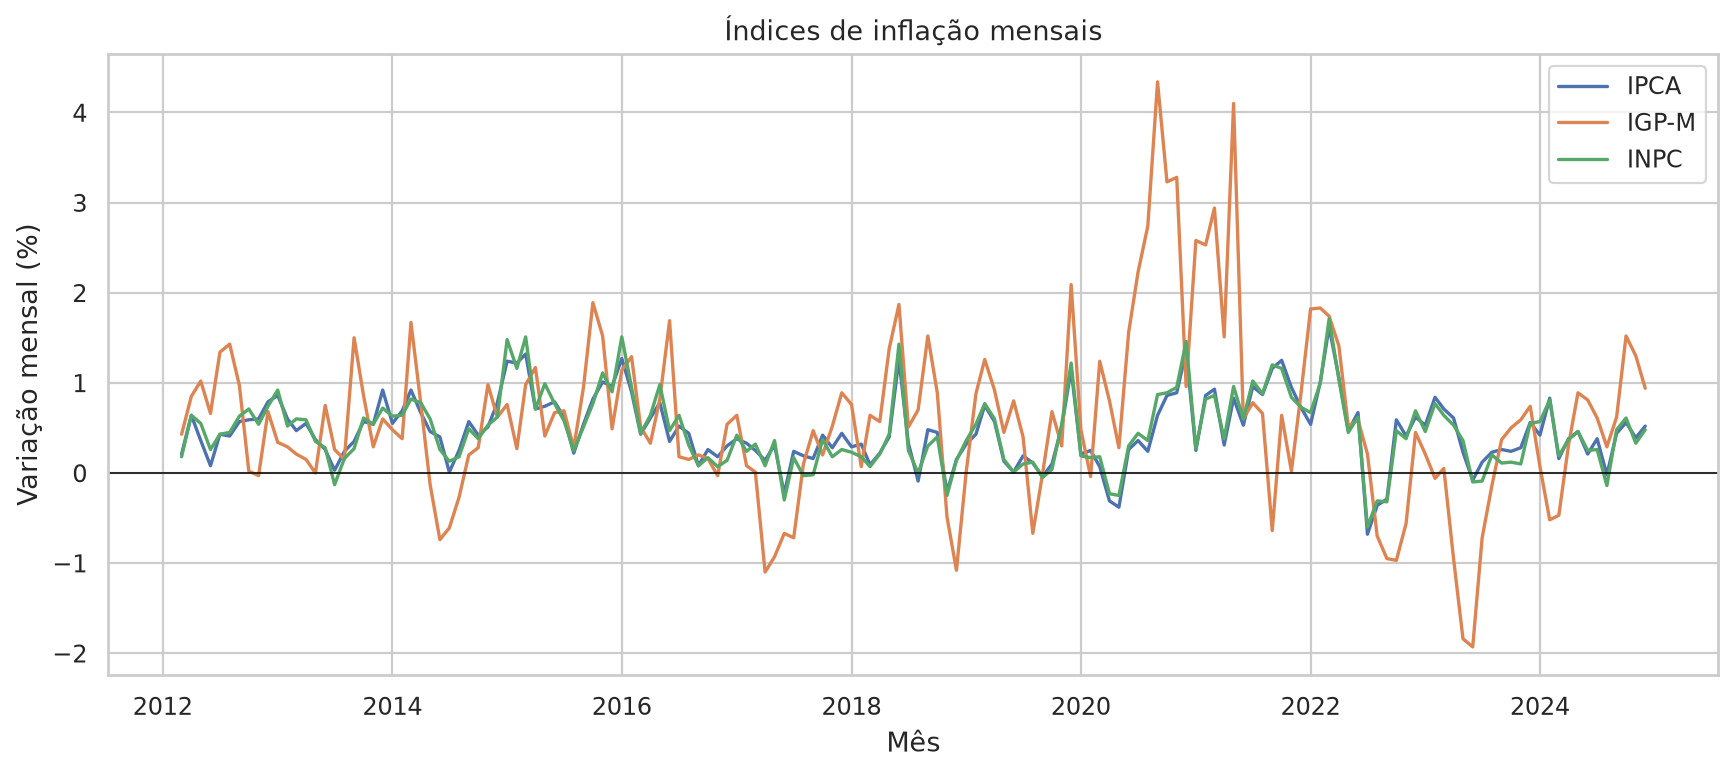

A evolução mensal do desemprego PNADC.


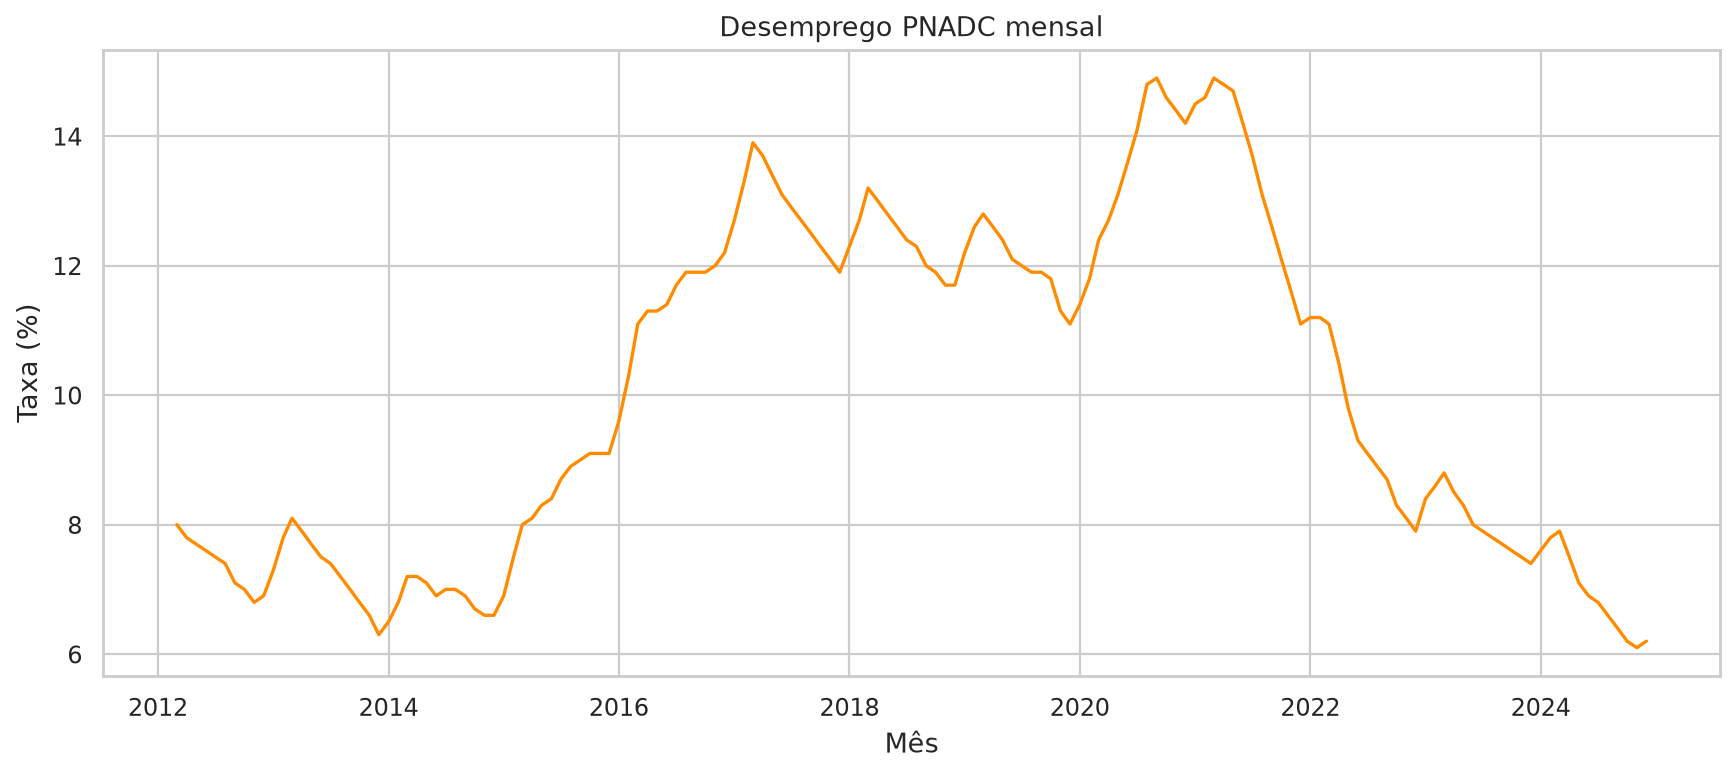

A mediana e a média dos retornos mensais da amostra.


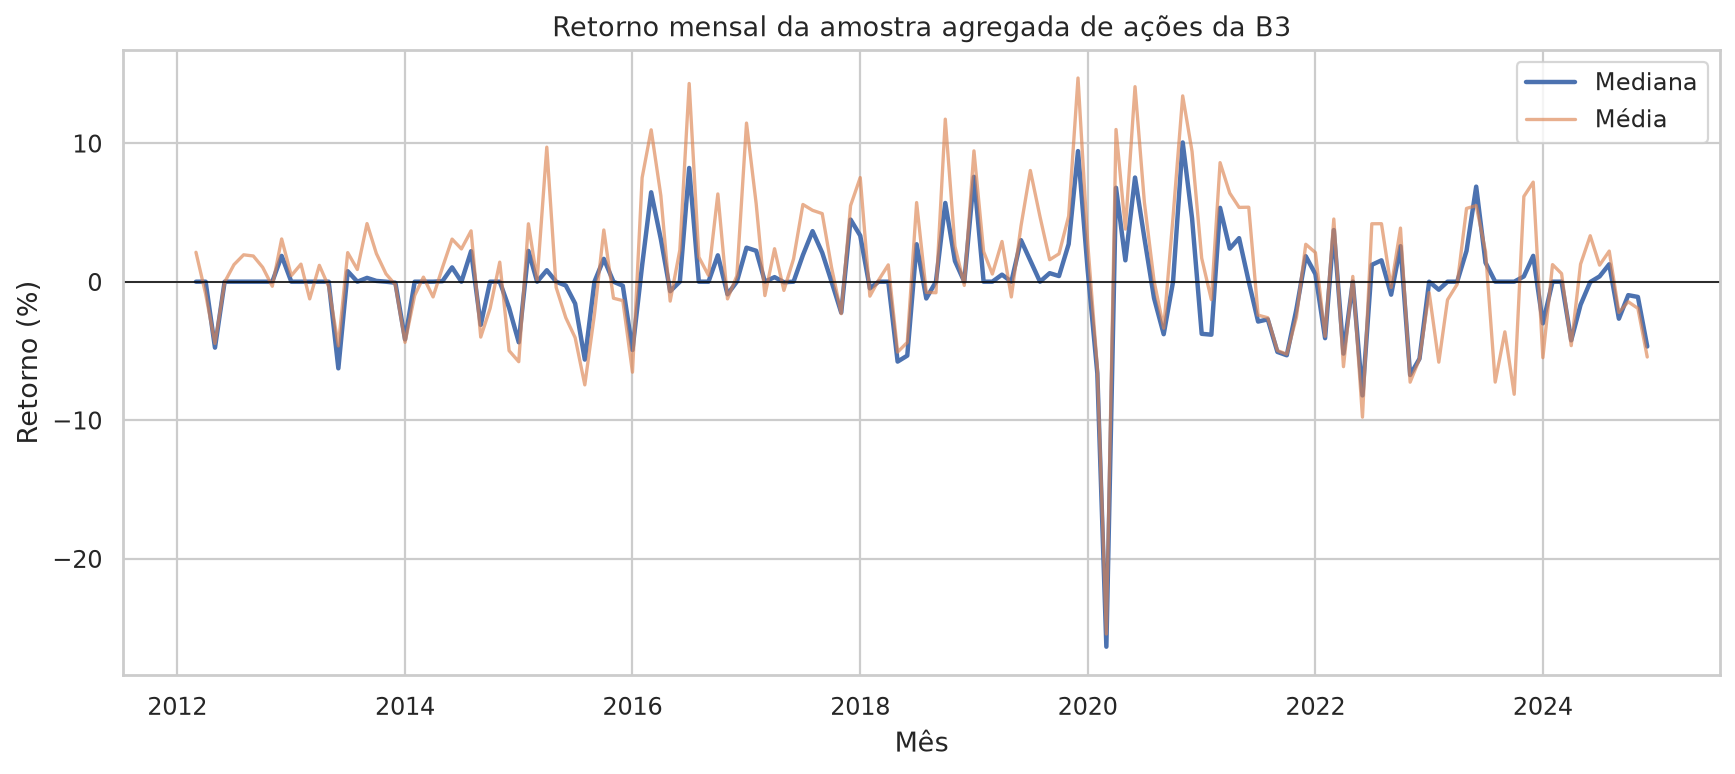

A mediana e a média da volatilidade diária mensal.


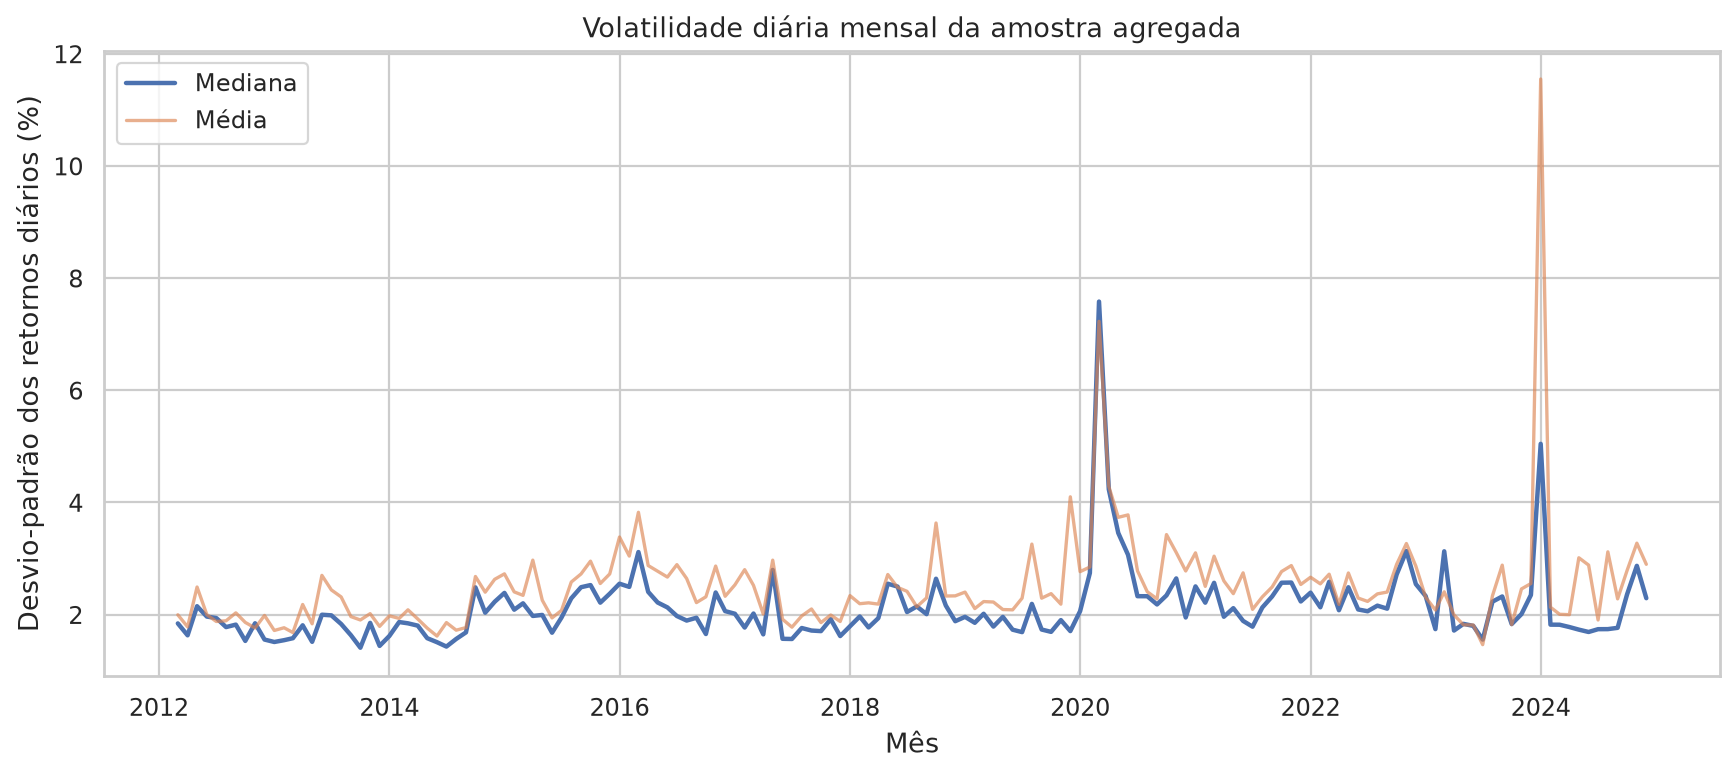

A distribuição visual dos retornos entre os percentis 1 e 99.


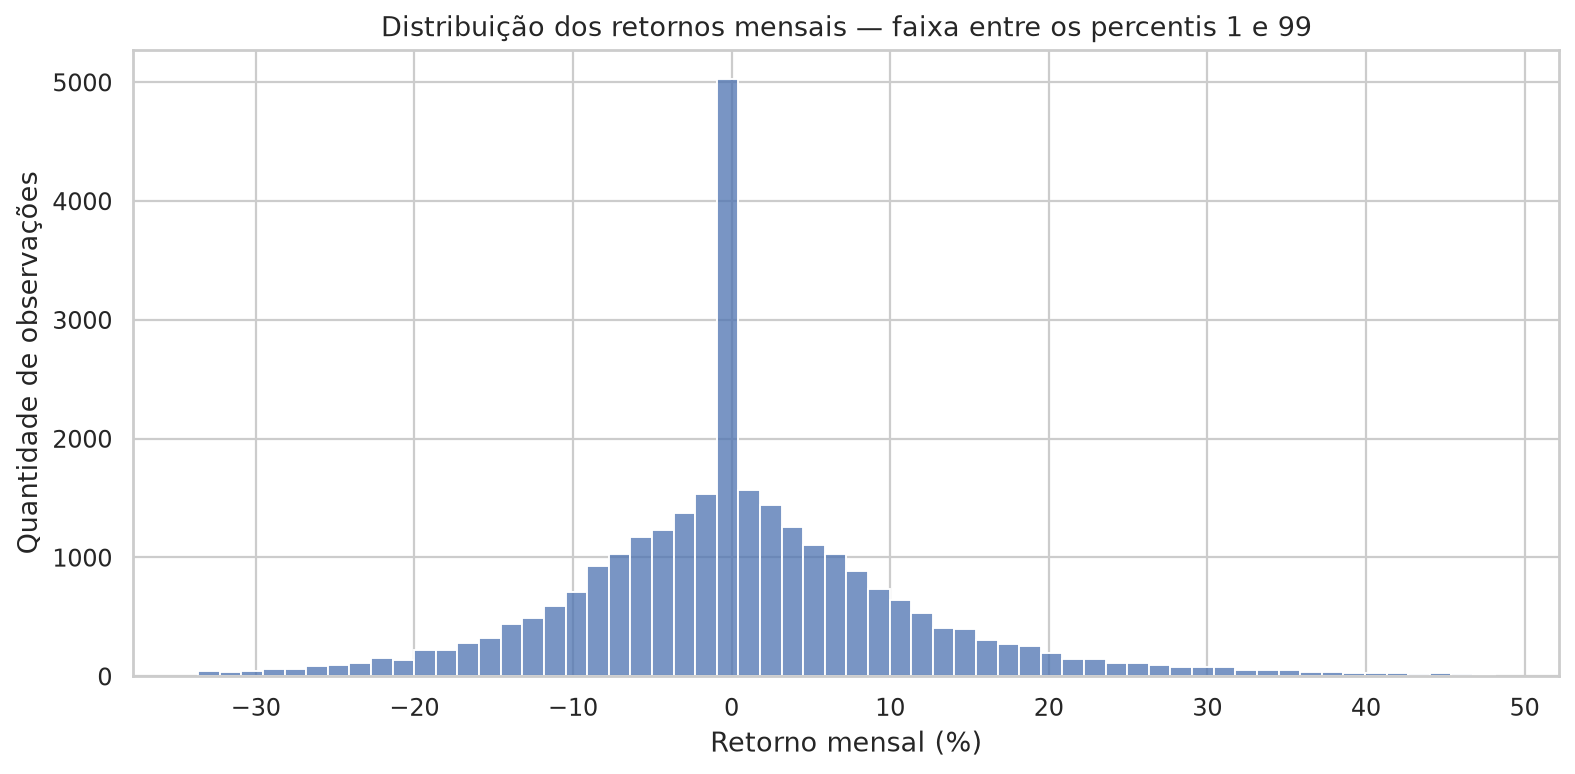

A proporção mensal de ativos com retorno positivo ou negativo.


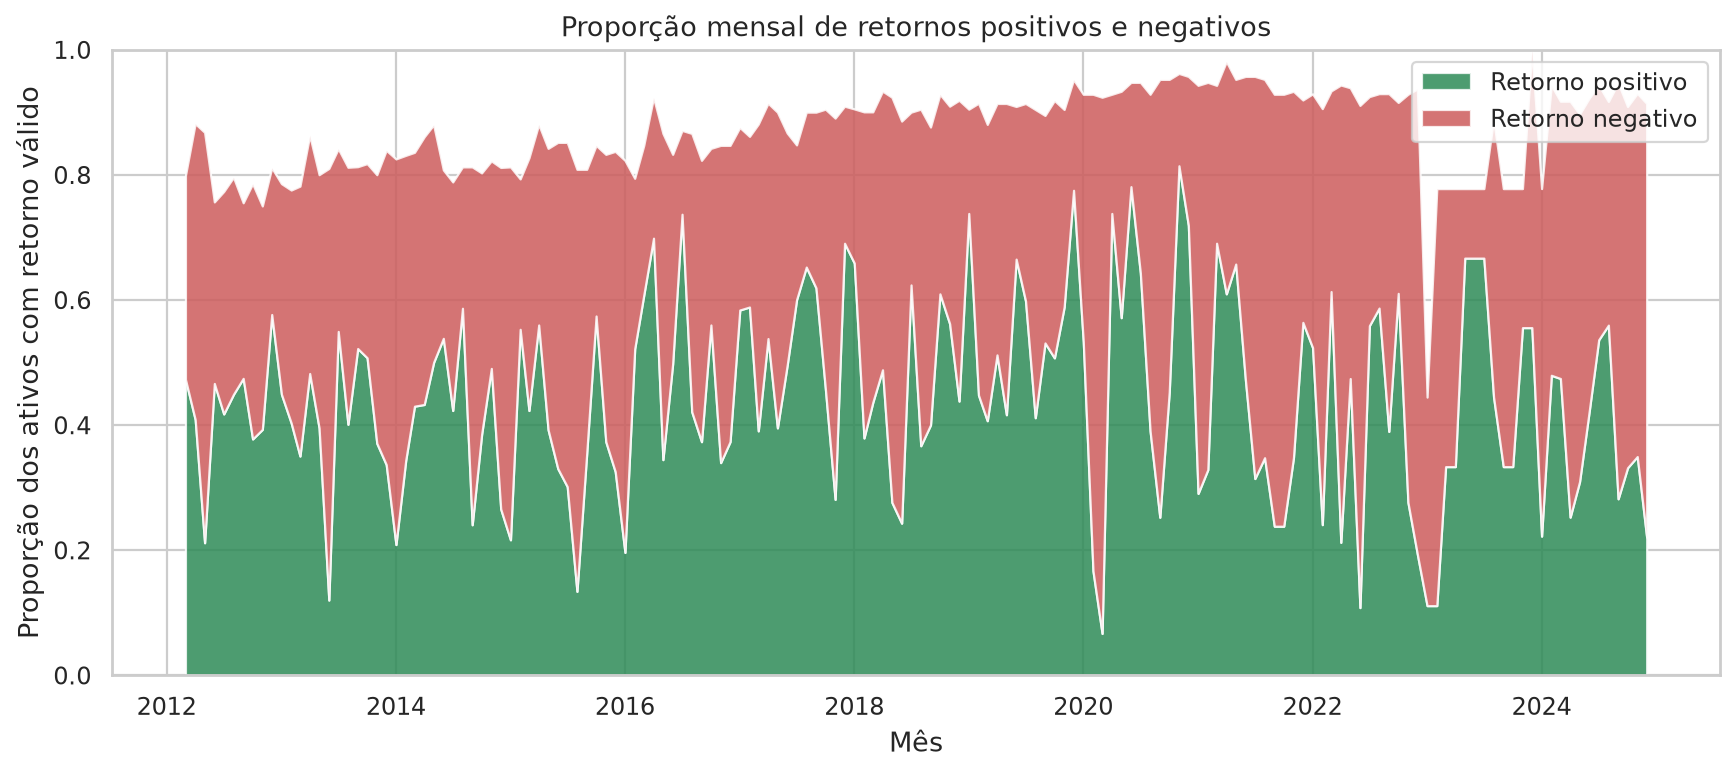

A quantidade de ativos disponíveis e com retorno válido por mês.


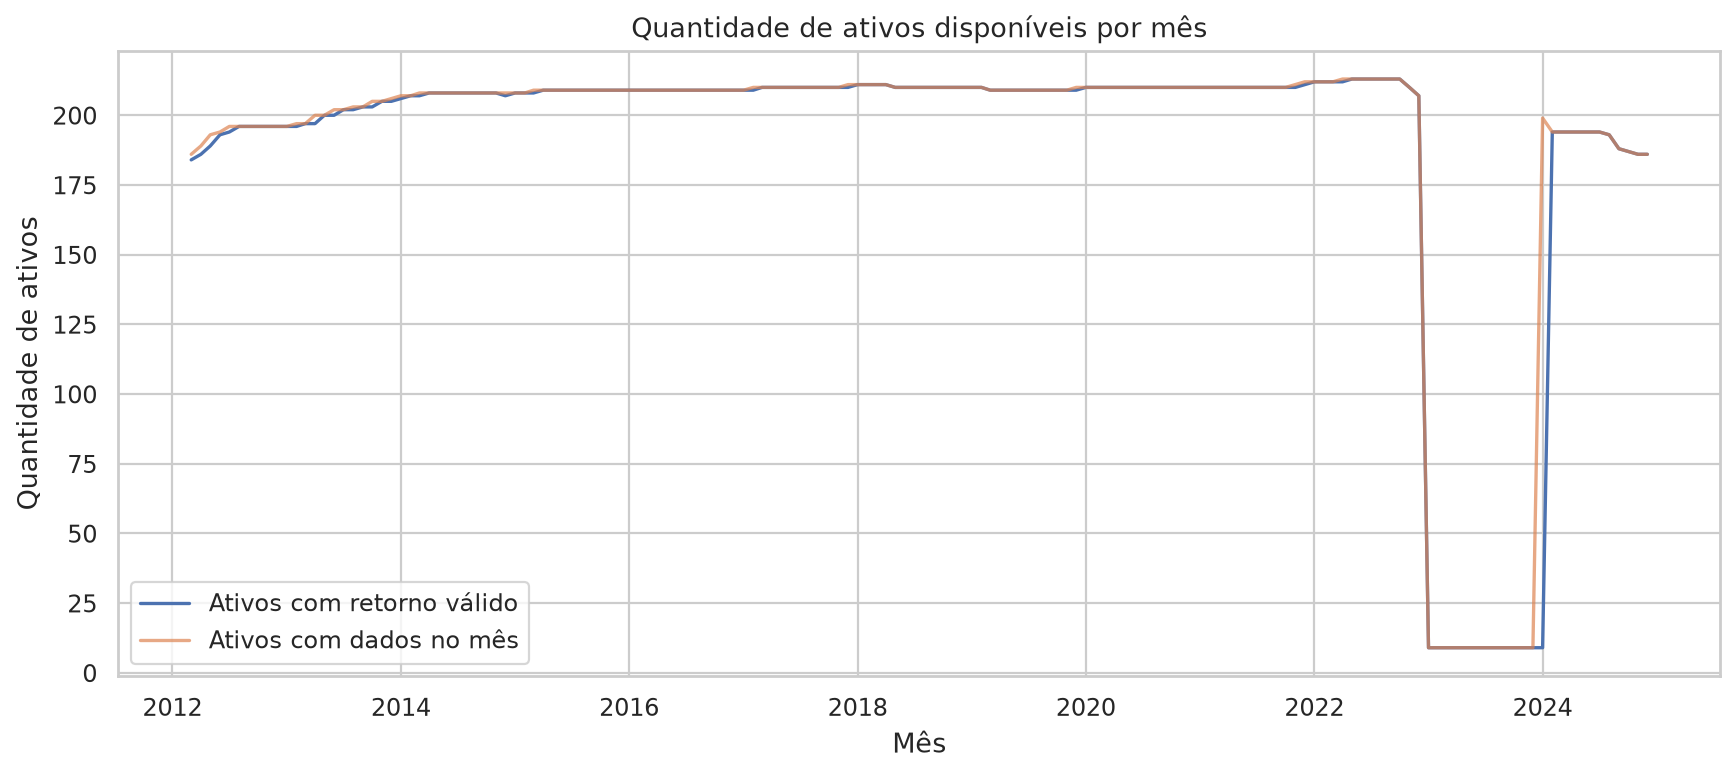

In [5]:
for name, explanation in [
    ('selic_historica.png', 'A evolução da Selic média mensal e ao final do mês.'),
    ('inflacao_historica.png', 'A evolução comparada dos índices mensais de inflação.'),
    ('desemprego_historico.png', 'A evolução mensal do desemprego PNADC.'),
    ('retorno_mediano_b3.png', 'A mediana e a média dos retornos mensais da amostra.'),
    ('volatilidade_mediana_b3.png', 'A mediana e a média da volatilidade diária mensal.'),
    ('distribuicao_retornos.png', 'A distribuição visual dos retornos entre os percentis 1 e 99.'),
    ('proporcao_retornos_positivos_negativos.png', 'A proporção mensal de ativos com retorno positivo ou negativo.'),
    ('ativos_validos_por_mes.png', 'A quantidade de ativos disponíveis e com retorno válido por mês.'),
]:
    print(explanation)
    display(Image(filename=str(FIGURES / name)))

## 6. Resultados preliminares

As observações desta etapa devem ser limitadas à distribuição dos dados, à evolução temporal dos indicadores, aos meses extremos e à estabilidade da quantidade de ativos. A presença de um movimento simultâneo não será interpretada como causalidade. A análise formal da associação entre ações e indicadores econômicos será realizada somente na Etapa 4.